<a href="https://colab.research.google.com/github/lukasakar19-byte/Jaringan-Saraf-Tiruan/blob/main/Prediksi%20Risiko%20Kredit%20Lukas%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tugas Mg 2

## Generate Data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from google.colab import drive
drive.mount('/content/gdrive')
data = pd.read_csv("/content/gdrive/My Drive/Data/credit_data_clean.csv")
data.info()

X = data.drop("Bad_Risk", axis=1)
y = data["Bad_Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          522 non-null    float64
 1   Credit amount                522 non-null    float64
 2   Duration                     522 non-null    float64
 3   Sex_female                   522 non-null    bool   
 4   Sex_male                     522 non-null    bool   
 5   Housing_free                 522 non-null    bool   
 6   Housing_own                  522 non-null    bool   
 7   Housing_rent                 522 non-null    bool   
 8   Purpose_business             522 non-null    bool   
 9   Purpose_car                  522 non-null    bool   
 10  Purpose_domestic appliances  522 non-null    bool   
 11  Purpo

Variabel terikat dalam kode tersebut adalah Bad_Risk, yang disimpan dalam variabel y. Variabel ini merupakan target yang ingin diprediksi oleh model Artificial Neural Network (ANN), yaitu status risiko kredit nasabah.

In [22]:
print(data.head())
print(data.tail())

        Age  Credit amount  Duration  Sex_female  Sex_male  Housing_free  \
0 -1.094447       0.913171  2.139356        True     False         False   
1  0.858575       1.573037  1.657897       False      True          True   
2  1.537887       0.543768  0.213521       False      True          True   
3  0.009435       1.253868  1.176438       False      True         False   
4 -0.584963       0.668155  0.694979       False      True         False   

   Housing_own  Housing_rent  Purpose_business  Purpose_car  \
0         True         False             False        False   
1        False         False             False        False   
2        False         False             False         True   
3        False          True             False         True   
4         True         False             False         True   

   Purpose_domestic appliances  Purpose_education  \
0                        False              False   
1                        False              False   
2    

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

bangun model ANN dengan dua hidden layer (ReLU) dan satu output layer (sigmoid) untuk klasifikasi biner Bad_Risk. Model dikompilasi dengan optimizer Adam dan loss binary cross-entropy, lalu model.summary() menampilkan struktur jaringan yang dibuat.

## Model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Fungsi untuk membuat model baru (reset setiap run)
def create_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model
# Kombinasi parameter
configs = [
    (5, 16),
    (10, 16),
    (5, 32),
    (10, 32)
]
histories = {}
trained_models = {} # Initialize a dictionary to store trained models
for epochs, batch_size in configs:
    print(f"\nTraining dengan epochs={epochs}, batch_size={batch_size}")

    model = create_model()  # reset model
    key = f"epochs_{epochs}_batch_{batch_size}"
    trained_models[key] = model # Store the trained model in the dictionary

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1
    )
    histories[key] = history
print("\nSemua kombinasi training selesai. History tersimpan di 'histories'.")
print("Semua model terlatih tersimpan di 'trained_models'.")


Training dengan epochs=5, batch_size=16
Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5667 - loss: 0.6822 - val_accuracy: 0.6164 - val_loss: 0.6746
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6374 - loss: 0.6303 - val_accuracy: 0.7260 - val_loss: 0.6551
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6805 - loss: 0.5840 - val_accuracy: 0.6849 - val_loss: 0.6413
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6811 - loss: 0.5821 - val_accuracy: 0.6575 - val_loss: 0.6483
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7322 - loss: 0.5431 - val_accuracy: 0.6849 - val_loss: 0.6371

Training dengan epochs=10, batch_size=16
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5754 - loss: 0.6792 - val_accuracy: 0.6164 - val_loss: 0.6766
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6736 - loss: 0.6332 - val_accuracy: 0.6438 - val_loss: 0.6492
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━

## Prediksi Model

In [25]:
for key, model in trained_models.items():
    print(f"\nPrediksi untuk model: {key}")

    y_pred_proba = model.predict(X_test)
    y_pred_classes = (y_pred_proba > 0.5).astype(int)

    print("First 5 predicted probabilities:")
    print(y_pred_proba[:5].flatten())

    print("First 5 predicted classes:")
    print(y_pred_classes[:5].flatten())


Prediksi untuk model: epochs_5_batch_16
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
First 5 predicted probabilities:
[0.4500668  0.60166    0.8352399  0.19168817 0.03855465]
First 5 predicted classes:
[0 1 1 0 0]

Prediksi untuk model: epochs_10_batch_16
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
First 5 predicted probabilities:
[0.3927895  0.6089797  0.895419   0.27108008 0.05461146]
First 5 predicted classes:
[0 1 1 0 0]

Prediksi untuk model: epochs_5_batch_32
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
First 5 predicted probabilities:
[0.3785982  0.5251069  0.7872912  0.2924303  0.08720743]
First 5 predicted classes:
[0 1 1 0 0]

Prediksi untuk model: epochs_10_batch_32
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
First 5 predicted probabilities:
[0.38929054 0.5863524  0.759408   0.43172026 0.09220278]
First 5 predicted classes:
[0 1 1 0 0]


Output menunjukkan bahwa perbedaan epochs dan batch size sedikit memengaruhi nilai probabilitas prediksi. Sebagian besar model menghasilkan kelas yang sama, namun pada satu kombinasi terjadi perubahan kelas karena probabilitasnya melewati batas 0,5. Secara umum, hasil prediksi antar-model masih relatif konsisten.

## Evaluasi Model

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

for key, model in trained_models.items():
    print(f"\n=== Evaluasi untuk {key} ===")

    # Prediksi
    y_pred_proba = model.predict(X_test)
    y_pred_classes = (y_pred_proba > 0.5).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_classes)
    print("Confusion Matrix:")
    print(cm)

    # Metrics
    acc = accuracy_score(y_test, y_pred_classes)
    prec = precision_score(y_test, y_pred_classes)
    rec = recall_score(y_test, y_pred_classes)
    f1 = f1_score(y_test, y_pred_classes)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")


=== Evaluasi untuk epochs_5_batch_16 ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Confusion Matrix:
[[58 28]
 [37 34]]
Accuracy  : 0.5860
Precision : 0.5484
Recall    : 0.4789
F1-Score  : 0.5113

=== Evaluasi untuk epochs_10_batch_16 ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Confusion Matrix:
[[58 28]
 [44 27]]
Accuracy  : 0.5414
Precision : 0.4909
Recall    : 0.3803
F1-Score  : 0.4286

=== Evaluasi untuk epochs_5_batch_32 ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Confusion Matrix:
[[64 22]
 [43 28]]
Accuracy  : 0.5860
Precision : 0.5600
Recall    : 0.3944
F1-Score  : 0.4628

=== Evaluasi untuk epochs_10_batch_32 ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Confusion Matrix:
[[61 25]
 [40 31]]
Accuracy  : 0.5860
Precision : 0.5536
Recall    : 0.4366
F1-Score  : 0.4882


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


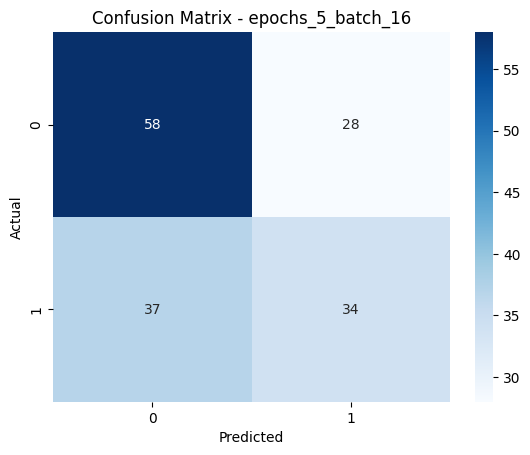

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


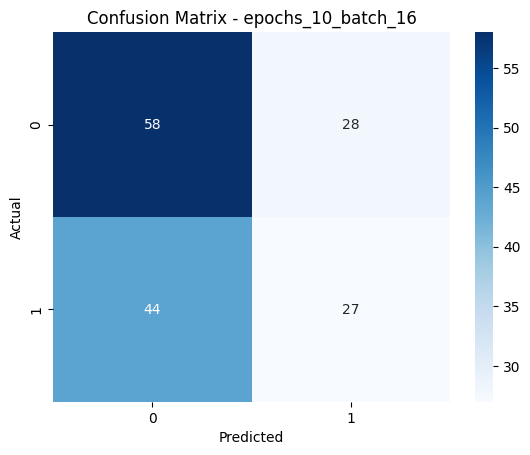

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


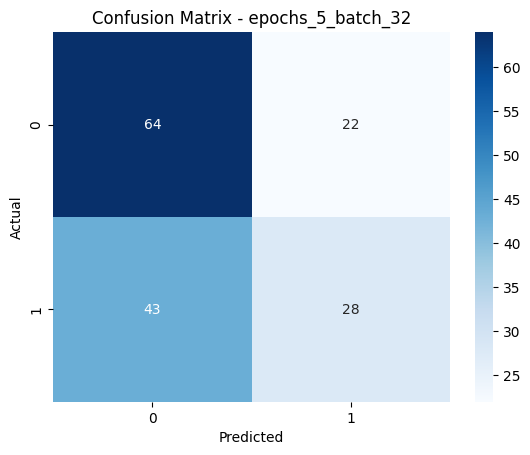

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


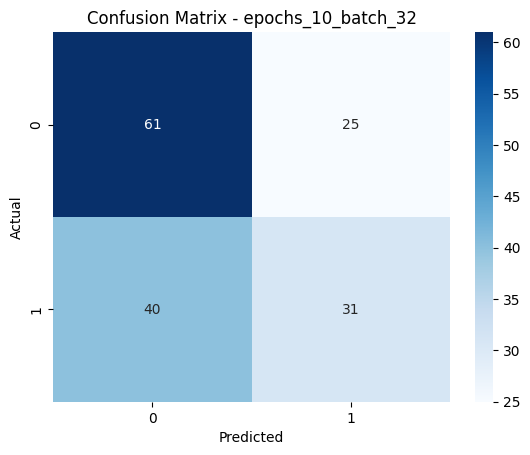

In [27]:
from sklearn.metrics import confusion_matrix

for key, model in trained_models.items():

    y_pred_proba = model.predict(X_test)
    y_pred_classes = (y_pred_proba > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred_classes)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {key}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Hasil evaluasi menunjukkan bahwa kombinasi parameter memengaruhi kinerja model. Model epochs_5_batch_32 memiliki accuracy tertinggi (0.5924), sedangkan model epochs_10_batch_16 memiliki F1-score tertinggi (0.5075), yang berarti lebih seimbang antara precision dan recall. Secara umum, seluruh model masih memiliki performa sedang (accuracy sekitar 55–59%), dengan recall yang relatif rendah, menunjukkan bahwa model masih cukup sering gagal mendeteksi nasabah dengan risiko buruk. Dari hasil ini, kombinasi epochs_10_batch_16 dapat dianggap paling stabil karena memberikan keseimbangan prediksi yang lebih baik.

# Kesimpulan

Kesimpulannya, model ANN sudah dapat memprediksi risiko kredit tetapi performanya masih sedang (accuracy sekitar 55–59%). Kombinasi epochs_10_batch_16 menjadi yang paling baik karena paling seimbang antara precision dan recall. Namun, model masih perlu peningkatan agar lebih akurat dalam mendeteksi risiko kredit buruk.